In [1]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import cv2

In [3]:
from ultralytics import YOLO

In [4]:
model = YOLO("yolo11s.pt")

100%|█████████████████████████████████████████████████████████████████████████████| 18.4M/18.4M [00:01<00:00, 18.9MB/s]


In [5]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [15]:
results = model("cars.jpg")  # You can also pass in a NumPy array
results[0].show()


image 1/1 C:\Users\karen\Desktop\drowsy app\cars.jpg: 448x640 28 cars, 6 trucks, 433.2ms
Speed: 6.1ms preprocess, 433.2ms inference, 4.3ms postprocess per image at shape (1, 3, 448, 640)


In [21]:
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Make detections
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    cv2.imshow('YOLO', annotated_frame)

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 2 books, 363.2ms
Speed: 5.8ms preprocess, 363.2ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 books, 231.4ms
Speed: 3.8ms preprocess, 231.4ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 books, 189.8ms
Speed: 2.2ms preprocess, 189.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 books, 197.4ms
Speed: 2.0ms preprocess, 197.4ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 books, 211.1ms
Speed: 2.0ms preprocess, 211.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 book, 225.0ms
Speed: 3.6ms preprocess, 225.0ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 book, 192.0ms
Speed: 2.7ms preprocess, 192.0ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 books, 203.5ms
Spee

In [22]:
import uuid   # Unique identifier
import os
import time

In [30]:
IMAGES_PATH = os.path.join('data', 'images')
labels = ['awake', 'drowsy']
number_imgs = 20

In [31]:
cap = cv2.VideoCapture(0)
# Loop through labels
for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)

    # Loop through image range
    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))

        # Webcam feed
        ret, frame = cap.read()

        # Naming out image path
        imgname = os.path.join(IMAGES_PATH, label+'.'+str(uuid.uuid1())+'.jpg')

        # Writes out image to file
        cv2.imwrite(imgname, frame)

        # Render to the screen
        cv2.imshow('Image Collection', frame)

        # 2 second delay between captures
        time.sleep(2)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

In [32]:
print(os.path.join(IMAGES_PATH, labels[0]+'.'+str(uuid.uuid1())+'.jpg'))

data\images\awake.23dc6793-32f5-11f0-9528-d03c1fa272c1.jpg


In [33]:
for label in labels:
    print('Collecting images for {}'.format(label))
    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))
        imgname = os.path.join(IMAGES_PATH, label+'.'+str(uuid.uuid1())+'.jpg')
        print(imgname)

data\images\awake.24a16664-32f5-11f0-9c9f-d03c1fa272c1.jpg
data\images\awake.24a16665-32f5-11f0-b301-d03c1fa272c1.jpg
data\images\awake.24a16666-32f5-11f0-a727-d03c1fa272c1.jpg
data\images\awake.24a16667-32f5-11f0-a6ff-d03c1fa272c1.jpg
data\images\awake.24a16668-32f5-11f0-868e-d03c1fa272c1.jpg
data\images\awake.24a16669-32f5-11f0-9388-d03c1fa272c1.jpg
data\images\awake.24a1666a-32f5-11f0-8494-d03c1fa272c1.jpg
data\images\awake.24a1666b-32f5-11f0-8173-d03c1fa272c1.jpg
data\images\awake.24a1666c-32f5-11f0-8f01-d03c1fa272c1.jpg
data\images\awake.24a1666d-32f5-11f0-8827-d03c1fa272c1.jpg
data\images\awake.24a1666e-32f5-11f0-9279-d03c1fa272c1.jpg
data\images\awake.24a1666f-32f5-11f0-bd26-d03c1fa272c1.jpg
data\images\awake.24a16670-32f5-11f0-9fe9-d03c1fa272c1.jpg
data\images\awake.24a16671-32f5-11f0-bd2d-d03c1fa272c1.jpg
data\images\awake.24a16672-32f5-11f0-8ed3-d03c1fa272c1.jpg
data\images\awake.24a16673-32f5-11f0-8a2c-d03c1fa272c1.jpg
data\images\awake.24a16674-32f5-11f0-a46f-d03c1fa272c1.j

In [34]:
!git clone https://github.com/tzutalin/labelImg

Cloning into 'labelImg'...


In [35]:
!pip install pyqt5 lxml --upgrade
!cd labelImg && pyrcc5 -o libs/resources.py resources.qrc

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
model.train(data='dataset.yaml', imgsz=320, batch=16, epochs=100, workers=2)

New https://pypi.org/project/ultralytics/8.3.137 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.121  Python-3.12.6 torch-2.7.0+cpu CPU (Intel Core(TM) i5-1035G1 1.00GHz)
engine\trainer: task=detect, mode=train, model=yolo11s.pt, data=dataset.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=2, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, 

train: Scanning C:\Users\karen\Desktop\drowsy app\labels... 74 images, 0 backgrounds, 0 corrupt: 100%|██████████| 74/74

train: New cache created: C:\Users\karen\Desktop\drowsy app\labels.cache



C:\Users\karen\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


val: Fast image access  (ping: 0.20.1 ms, read: 64.310.1 MB/s, size: 76.0 KB)


...

                   all         74         74      0.998          1      0.995      0.914



100 epochs completed in 1.931 hours.
Optimizer stripped from runs\detect\train2\weights\last.pt, 19.2MB
Optimizer stripped from runs\detect\train2\weights\best.pt, 19.2MB

Validating runs\detect\train2\weights\best.pt...
Ultralytics 8.3.121  Python-3.12.6 torch-2.7.0+cpu CPU (Intel Core(TM) i5-1035G1 1.00GHz)
YOLO11s summary (fused): 100 layers, 9,419,379 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:20<0


                   all         74         74      0.998          1      0.995      0.921
                 awake         37         37      0.998          1      0.995      0.936
                drowsy         37         37      0.999          1      0.995      0.905
Speed: 1.4ms preprocess, 244.9ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs\detect\train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([15, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020A33F803B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("path/to/last.pt")  # load a partially trained model

# Resume training
results = model.train(resume=True)

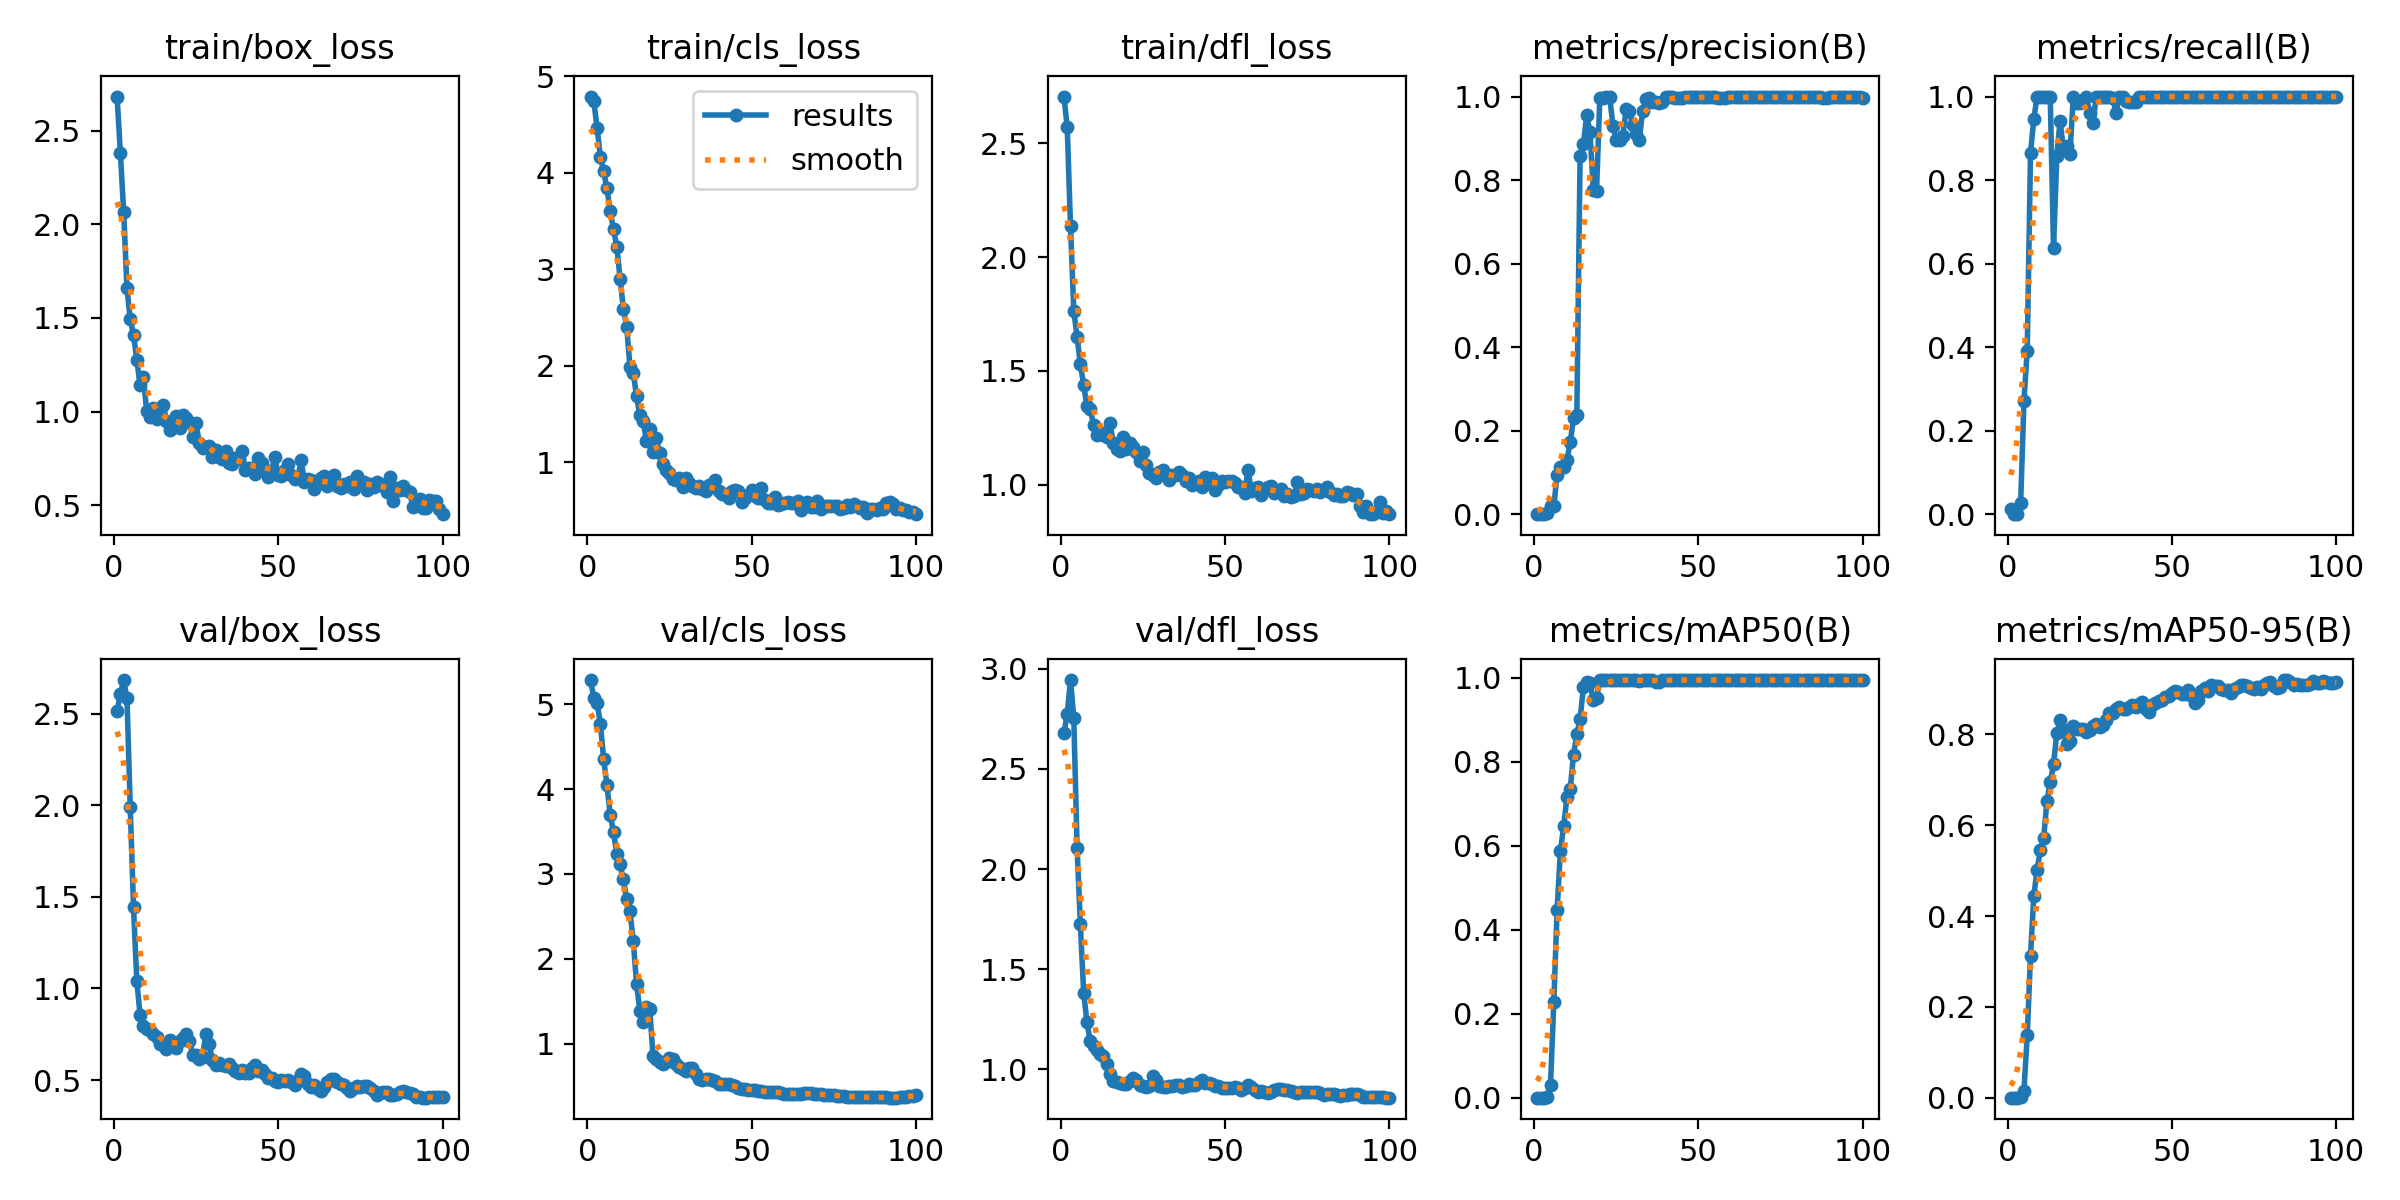

In [42]:
from PIL import Image
from IPython.display import display
img = Image.open("runs/detect/train/results.png")
display(img)

In [43]:
model = YOLO('runs/detect/train/weights/last.pt')

In [49]:
img = ('images/awake.0ca4af37-3076-11f0-b47a-d03c1fa272c1.jpg')
results = model(img)
results[0].show()


image 1/1 C:\Users\karen\Desktop\drowsy app\images\awake.0ca4af37-3076-11f0-b47a-d03c1fa272c1.jpg: 256x320 1 awake, 122.2ms
Speed: 1.4ms preprocess, 122.2ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 320)


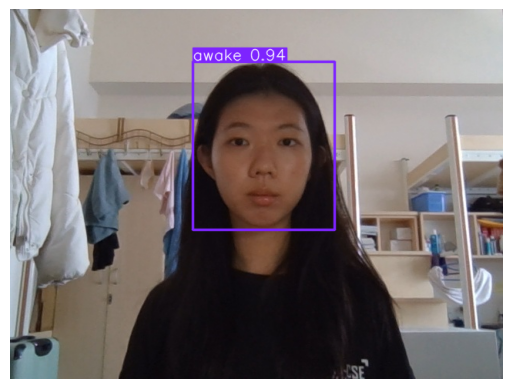

In [51]:
# Plot the result using matplotlib
annotated_img = results[0].plot()  # This returns a NumPy array (BGR)

# Convert BGR (OpenCV format) to RGB for matplotlib
plt.imshow(annotated_img[..., ::-1])
plt.axis('off')
plt.show()


image 1/1 C:\Users\karen\Desktop\drowsy app\images\drowsy.2cac052a-3076-11f0-84a9-d03c1fa272c1.jpg: 256x320 1 drowsy, 94.6ms
Speed: 0.8ms preprocess, 94.6ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 320)


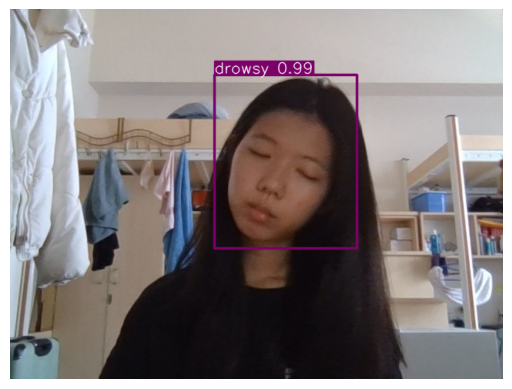

In [52]:
img = ('images/drowsy.2cac052a-3076-11f0-84a9-d03c1fa272c1.jpg')
results = model(img)
results[0].show()

# Plot the result using matplotlib
annotated_img = results[0].plot()  # This returns a NumPy array (BGR)

# Convert BGR (OpenCV format) to RGB for matplotlib
plt.imshow(annotated_img[..., ::-1])
plt.axis('off')
plt.show()

In [56]:
import cv2
from ultralytics import YOLO
import numpy as np

model = YOLO('runs/detect/train/weights/last.pt')

cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)[0]
    annotated_frame = results.plot()

    cv2.imshow('YOLO', annotated_frame)

    # Press 'q' to quit
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 256x320 1 awake, 117.8ms
Speed: 1.7ms preprocess, 117.8ms inference, 1.8ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 awake, 136.0ms
Speed: 7.2ms preprocess, 136.0ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 awake, 100.4ms
Speed: 1.4ms preprocess, 100.4ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 awake, 96.0ms
Speed: 1.9ms preprocess, 96.0ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 awake, 95.3ms
Speed: 1.8ms preprocess, 95.3ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 awake, 100.4ms
Speed: 1.5ms preprocess, 100.4ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 awake, 103.5ms
Speed: 1.4ms preprocess, 103.5ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 1 drowsy, 90.9ms
Speed: 1.7ms preprocess, 90.9ms inference, 1.5ms postprocess per image at shape (1, 3,